In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

MNIST Conditional Flow Matching Framework

built a small but fully functional continuous-time generative flow model using a time-conditioned U-Net. The framework compares two parameterizations for learning transport dynamics between image distributions:

Velocity prediction (v-prediction)
Endpoint prediction (x₁-prediction)

The model learns a continuous transformation from MNIST digit 0 to MNIST digit 2.





Using device: cuda

Training U-Net v-prediction model...
  Step 0000 | Loss: 0.1711

Training U-Net x-prediction model...
  Step 0000 | Loss: 0.1350

Generating comparative samples...


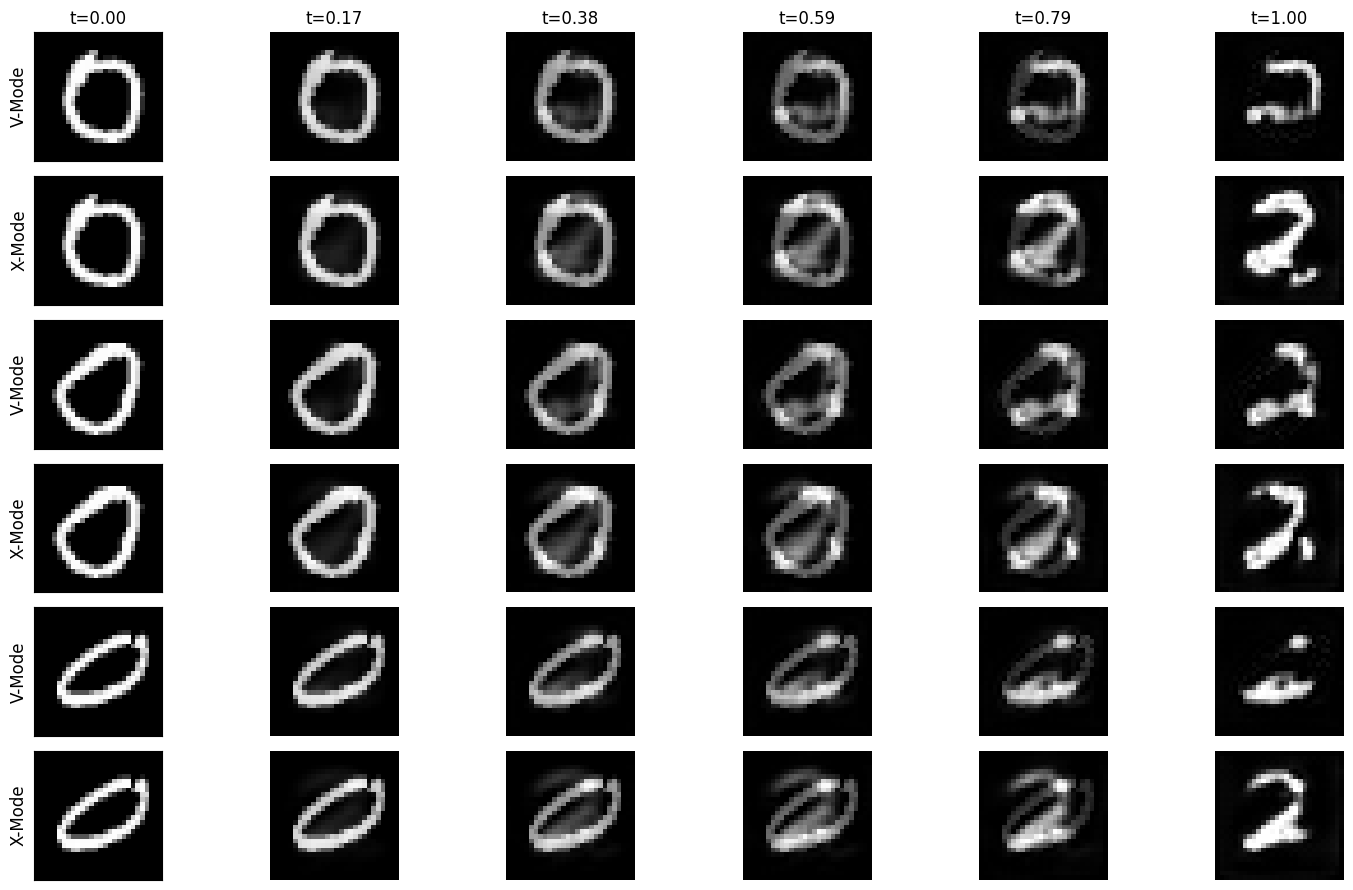

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def get_mnist_digits(target_digit):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    idx = dataset.targets == target_digit
    images = dataset.data[idx].float() / 255.0
    return images.unsqueeze(1)

# ---------------------------------------------------------
# 1. THE U-NET ARCHITECTURE
# ---------------------------------------------------------
class DoubleConv(nn.Module):
    """(Conv => SiLU) * 2 with Time Injection"""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)

    def forward(self, x, t_emb):
        h = F.silu(self.conv1(x))
        # Inject time embedding
        time_val = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_val
        h = F.silu(self.conv2(h))
        return h

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_dim = 64
        self.time_mlp = nn.Sequential(
            nn.Linear(1, self.time_dim),
            nn.SiLU(),
            nn.Linear(self.time_dim, self.time_dim)
        )

        # Downward Path
        self.down1 = DoubleConv(1, 32, self.time_dim)
        self.pool1 = nn.MaxPool2d(2) # 28x28 -> 14x14
        
        self.down2 = DoubleConv(32, 64, self.time_dim)
        self.pool2 = nn.MaxPool2d(2) # 14x14 -> 7x7

        # Bottleneck (Global Vision)
        self.bot = DoubleConv(64, 128, self.time_dim)

        # Upward Path
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 7x7 -> 14x14
        self.up_conv1 = DoubleConv(128, 64, self.time_dim) # 64 + 64 (skip) = 128
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) # 14x14 -> 28x28
        self.up_conv2 = DoubleConv(64, 32, self.time_dim) # 32 + 32 (skip) = 64

        # Output Layer
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Down
        x1 = self.down1(x, t_emb)
        x2 = self.down2(self.pool1(x1), t_emb)
        
        # Bottleneck
        x3 = self.bot(self.pool2(x2), t_emb)
        
        # Up + Skip Connections
        x_up1 = self.up1(x3)
        x4 = self.up_conv1(torch.cat([x_up1, x2], dim=1), t_emb)
        
        x_up2 = self.up2(x4)
        x5 = self.up_conv2(torch.cat([x_up2, x1], dim=1), t_emb)
        
        return self.out_conv(x5)

def train_step(model, opt, x0, x1, mode, device):
    model.train()

    batch_size = x0.size(0)

    # --------------------------------------------------
    # v-prediction
    # --------------------------------------------------
    if mode == "v":

        t = torch.rand((batch_size, 1), device=device)

        t_img = t[:, :, None, None]

        xt = (1 - t_img) * x0 + t_img * x1

        v_true = x1 - x0

        v_pred = model(xt, t)

        loss = F.mse_loss(v_pred, v_true)

    # --------------------------------------------------
    # x1-prediction
    # --------------------------------------------------
    elif mode == "x":

        t = torch.rand((batch_size, 1), device=device)

        t_img = t[:, :, None, None]

        xt = (1 - t_img) * x0 + t_img * x1

        # model predicts endpoint directly
        x1_pred = model(xt, t)

        # stable objective
        loss = F.mse_loss(x1_pred, x1)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    opt.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    opt.step()

    return loss.item()



@torch.no_grad()
@torch.no_grad()
def sample_and_plot(models, zeros, device):

    n_samples = 3
    steps = 30

    idx = torch.randint(0, len(zeros), (n_samples,))
    x_start = zeros[idx].to(device)

    t_vals = torch.linspace(0, 1, steps, device=device)

    fig, axes = plt.subplots(
        n_samples * 2,
        6,
        figsize=(15, n_samples * 3)
    )

    plot_indices = torch.linspace(0, steps - 1, 6).long()

    for m_idx, (mode, model) in enumerate(models.items()):

        model.eval()

        xt = x_start.clone()

        trajectories = [xt.cpu()]

        for i in range(steps - 1):

            t = t_vals[i]

            dt = t_vals[i + 1] - t_vals[i]

            t_batch = torch.full(
                (n_samples, 1),
                t,
                device=device
            )

            pred = model(xt, t_batch)

            if mode == "v":

                v_pred = pred

            elif mode == "x":

                denom = torch.clamp(1 - t, min=1e-3)

                v_pred = (pred - xt) / denom

            xt = xt + v_pred * dt

            xt = xt.clamp(0, 1)

            trajectories.append(xt.cpu())

        for i in range(n_samples):

            row = (i * 2) + m_idx

            for j, step_idx in enumerate(plot_indices):

                ax = axes[row, j]

                img = trajectories[step_idx][i].squeeze().numpy()

                ax.imshow(
                    img,
                    cmap='gray',
                    vmin=0,
                    vmax=1
                )

                ax.axis('off')

                if i == 0 and m_idx == 0:
                    ax.set_title(
                        f"t={t_vals[step_idx].item():.2f}"
                    )

                if j == 0:
                    ax.set_ylabel(
                        f"{mode.upper()}-Mode",
                        fontsize=12
                    )

                    ax.axis('on')
                    ax.set_xticks([])
                    ax.set_yticks([])

    plt.tight_layout()

    plt.show()
def run_comparison():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    zeros = get_mnist_digits(0).to(device)
    twos = get_mnist_digits(2).to(device)
    
    modes = ["v", "x"]
    models = {}
    batch_size = 128
    epochs = 500  # You might want to increase this to 3000 if you have a fast GPU
    
    for mode in modes:
        print(f"\nTraining U-Net {mode}-prediction model...")
        model = UNet().to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        for step in range(epochs):
            idx0 = torch.randint(0, len(zeros), (batch_size,))
            idx1 = torch.randint(0, len(twos), (batch_size,))
            
            loss = train_step(model, opt, zeros[idx0], twos[idx1], mode, device)
            
            if step % 500 == 0:
                print(f"  Step {step:04d} | Loss: {loss:.4f}")
                
        models[mode] = model
        
    print("\nGenerating comparative samples...")
    sample_and_plot(models, zeros, device)

if __name__ == "__main__":
    run_comparison()